# Proyecto Final - Clase 2: Predicción del estado fetal a partir de CTG

**Autor:** Lino Bossio
**Dataset:** `ASI_casoPractico.csv` (Cardiotocografía — CTG, 2126 registros)

Este proyecto reúne y cierra el trabajo de los sprints 4, 5 y 6: parto del análisis
descriptivo del sprint 4, paso por el modelo de Naive Bayes del sprint 5 y por el SVM del
sprint 6, y termino ajustando el mejor algoritmo posible para estimar el **estado fetal**
(`Target`: 0 = normal, 1 = anormal) a partir de las variables registradas por el
cardiotocógrafo (frecuencia cardíaca fetal, movimientos, contracciones uterinas y sus
histogramas asociados).

## Fases del proyecto
1. Carga de datos y análisis descriptivo.
2. Muestreo: conjunto de entrenamiento y test.
3. Ajuste del algoritmo de Naive Bayes.
4. Ajuste del algoritmo de Support Vector Machine.
5. Validación (curva ROC, AUC, matriz de confusión, precisión) y evaluación de sobreajuste.
6. Fase adicional: búsqueda de la mejor combinación de hiperparámetros para SVM con Grid Search.

## Fase 1 — Carga de datos y análisis descriptivo

In [1]:
# IMPORTACION DE LIBRERIAS
import numpy as np
import pandas as pd

# LIBRERIAS PARA HACER GRAFICOS
import seaborn as sns
import matplotlib.pyplot as plt

# MODELIZACION Y VALIDACION
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Configuracion de warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# CARGA DEL FICHERO DE DATOS
# En Colab, descomenta estas dos lineas para subir el CSV desde tu equipo:
# from google.colab import files
# files.upload()

file = 'ASI_casoPractico.csv'
data = pd.read_csv(file, sep=';', encoding='utf-8-sig')

print('Dimensiones (filas, columnas):', data.shape)
data.head()

Dimensiones (filas, columnas): (2126, 26)


,ID,b,e,LBE,AC,FM,UC,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Target
0,1,240,357,120,0,0,0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,1
1,2,5,632,132,4,0,4,17,2.1,0,...,68,198,6,1,141,136,140,12,0,0
2,3,177,779,133,2,0,5,16,2.1,0,...,68,198,5,1,141,135,138,13,0,0
3,4,411,1192,134,2,0,6,16,2.4,0,...,53,170,11,0,137,134,137,13,1,0
4,5,533,1147,132,4,0,5,16,2.4,0,...,53,170,9,0,137,136,138,11,1,0


### 1.1 — Eliminación de columnas no informativas

Se eliminan `ID` (identificador), `b`/`e` (instante de inicio/fin del segmento, sin valor
predictivo) y `DR` (deceleraciones repetitivas), que en el sprint 4 se comprobó que toma un
único valor (0) en las 2126 observaciones y por tanto no aporta información.

In [3]:
# ELIMINAR COLUMNAS NO NECESARIAS (identificadores / sin informacion)
data = data.drop(["ID", "b", "e", "DR"], axis=1)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LBE       2126 non-null   int64  
 1   AC        2126 non-null   int64  
 2   FM        2126 non-null   int64  
 3   UC        2126 non-null   int64  
 4   ASTV      2126 non-null   int64  
 5   MSTV      2126 non-null   float64
 6   ALTV      2126 non-null   int64  
 7   MLTV      2126 non-null   float64
 8   DL        2126 non-null   int64  
 9   DS        2126 non-null   int64  
 10  DP        2126 non-null   int64  
 11  Width     2126 non-null   int64  
 12  Min       2126 non-null   int64  
 13  Max       2126 non-null   int64  
 14  Nmax      2126 non-null   int64  
 15  Nzeros    2126 non-null   int64  
 16  Mode      2126 non-null   int64  
 17  Mean      2126 non-null   int64  
 18  Median    2126 non-null   int64  
 19  Variance  2126 non-null   int64  
 20  Tendency  2126 non-null   int64  
 21  Ta

### 1.2 — El target: proporción de estados fetales

Como ya se vio en el sprint 4, `Target` está desbalanceado: hay muchos más registros de
estado fetal normal que anormal. Lo recupero aquí porque condiciona cómo se leen luego la
matriz de confusión y la precisión (con clases desbalanceadas, la precisión global puede ser
engañosa si el modelo se limita a predecir siempre la clase mayoritaria).

In [4]:
# PROPORCION DEL TARGET
conteo = data['Target'].value_counts().sort_index()
proporcion = data['Target'].value_counts(normalize=True).sort_index()

tabla = pd.DataFrame({
    'estado': ['Normal (0)', 'Anormal (1)'],
    'frecuencia': conteo.values,
    'porcentaje': (proporcion.values * 100).round(2)
})
print(tabla.to_string(index=False))

     estado  frecuencia  porcentaje
 Normal (0)        1655       77.85
Anormal (1)         471       22.15


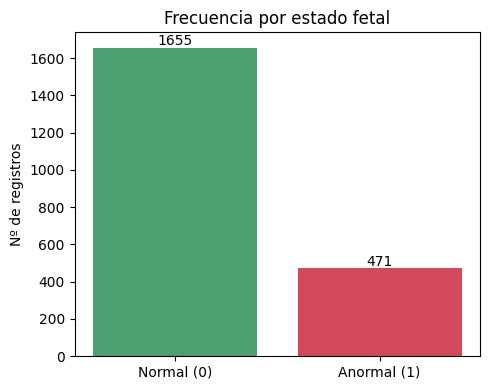

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Normal (0)', 'Anormal (1)'], conteo.values, color=['#4C9F70', '#D1495B'])
ax.set_title('Frecuencia por estado fetal')
ax.set_ylabel('Nº de registros')
for i, v in enumerate(conteo.values):
    ax.text(i, v + 15, str(v), ha='center')
plt.tight_layout()
plt.show()

### 1.3 — Correlación de las variables explicativas con el target

Igual que en el sprint 5, calculo la correlación (en valor absoluto) de cada variable
explicativa con `Target` para saber cuáles pesan más antes de modelizar.

In [6]:
# CORRELACION DE CADA VARIABLE EXPLICATIVA CON EL TARGET
corr_target = data.corr()["Target"].drop("Target")
corr_ranking = corr_target.abs().sort_values(ascending=False)
print(corr_ranking)

ASTV        0.493391
ALTV        0.489400
AC          0.369470
DP          0.340647
LBE         0.251875
UC          0.213611
MSTV        0.207717
MLTV        0.172519
Min         0.158171
Width       0.142182
Mode        0.092320
DS          0.087967
Variance    0.085948
Tendency    0.066529
Nmax        0.060354
Mean        0.059107
Max         0.048106
Median      0.047890
FM          0.043953
Nzeros      0.031163
DL          0.029696
Name: Target, dtype: float64


### 1.4 — Creación de nuevas variables

Las tres primeras posiciones del ranking anterior son `ASTV`, `ALTV` (ambas miden variabilidad
anormal de la frecuencia cardíaca, una a corto y otra a largo plazo) y `AC` (aceleraciones).
Pruebo dos variables nuevas construidas a partir de las ya existentes:

- **`Abn_Variability = ASTV + ALTV`**: combina en un único indicador el porcentaje de tiempo
  con variabilidad anormal, tanto a corto como a largo plazo.
- **`Decel_Total = DL + DS + DP`**: número total de deceleraciones de cualquier tipo (ligera,
  severa o prolongada), ya que `DR` se descartó por no variar.

Compruebo la correlación de ambas con el target antes de decidir si las incorporo al modelo.

In [7]:
# VARIABLES DERIVADAS
data['Abn_Variability'] = data['ASTV'] + data['ALTV']
data['Decel_Total'] = data['DL'] + data['DS'] + data['DP']

nuevas_corr = data[['Abn_Variability', 'Decel_Total']].corrwith(data['Target']).abs()
print(nuevas_corr)

Abn_Variability    0.575050
Decel_Total        0.033209
dtype: float64


**Lo que veo aquí.** `Abn_Variability` correlaciona con el target (0.575) por encima de
`ASTV` (0.493) y `ALTV` (0.489) por separado: combinar ambas variabilidades anormales en un
solo indicador refuerza la señal, así que la mantengo como variable explicativa.
`Decel_Total`, en cambio, correlaciona muy poco (0.033) — bastante menos que `DP` por sí sola
(0.341) — porque `DL` y `DS` son casi siempre cero y diluyen la señal de `DP` al sumarlas.
La descarto y elimino del dataset de modelización, dejando las variables de deceleración
individuales tal cual estaban.

In [8]:
# SE DESCARTA Decel_Total: diluye la señal de DP sin aportar valor
data = data.drop(columns=['Decel_Total'])
data.head()

,LBE,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Target,Abn_Variability
0,120,0,0,0,73,0.5,43,2.4,0,0,...,126,2,0,120,137,121,73,1,1,116
1,132,4,0,4,17,2.1,0,10.4,2,0,...,198,6,1,141,136,140,12,0,0,17
2,133,2,0,5,16,2.1,0,13.4,2,0,...,198,5,1,141,135,138,13,0,0,16
3,134,2,0,6,16,2.4,0,23.0,2,0,...,170,11,0,137,134,137,13,1,0,16
4,132,4,0,5,16,2.4,0,19.9,0,0,...,170,9,0,137,136,138,11,1,0,16


### 1.5 — Conclusiones de la Fase 1

- El dataset tiene 2126 registros y ninguna columna con valores nulos.
- El target está desbalanceado: 77.8 % de estados normales frente a 22.2 % anormales.
- Las variables más correlacionadas con el target son las de variabilidad anormal de la
  frecuencia cardíaca (`ASTV`, `ALTV`) y el número de aceleraciones (`AC`).
- La variable derivada `Abn_Variability` (suma de `ASTV` y `ALTV`) mejora la correlación
  individual de sus componentes y se incorpora al conjunto de variables explicativas.

## Fase 2 — Muestreo: conjunto de entrenamiento y test

Se reproduce el mismo muestreo de los sprints 5 y 6: **60 % entrenamiento / 40 % test**
con `random_state=0`, de modo que los conjuntos son reproducibles y comparables entre los
distintos algoritmos que se ajustan en este proyecto.

In [9]:
# MUESTREO: ENTRENAMIENTO (60%) Y TEST (40%)
X = data.loc[:, data.columns != "Target"]
y = data.loc[:, data.columns == "Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.60, random_state=0
)

print(f"Entrenamiento: {X_train.shape[0]} observaciones ({X_train.shape[0] / len(X):.0%})")
print(f"Test:          {X_test.shape[0]} observaciones ({X_test.shape[0] / len(X):.0%})")

Entrenamiento: 1275 observaciones (60%)
Test:          851 observaciones (40%)


## Fase 3 — Ajuste del algoritmo de Naive Bayes

In [10]:
# MODELIZACION - NAIVE BAYES
gnb = GaussianNB()
modelNB = gnb.fit(X_train, y_train.values.ravel())

y_pred_train_nb = modelNB.predict_proba(X_train)
y_pred_test_nb = modelNB.predict_proba(X_test)
pred_train_nb = modelNB.predict(X_train)
pred_test_nb = modelNB.predict(X_test)

## Fase 4 — Ajuste del algoritmo de Support Vector Machine

Igual que en el sprint 6, se ajusta `svm.SVC()` dejando los **valores por defecto**
(kernel `rbf`, `C=1.0`, `gamma='scale'`), añadiendo `probability=True` para poder obtener las
probabilidades que necesita la curva ROC.

In [11]:
# MODELIZACION - SVM CON VALORES POR DEFECTO
svm_default = SVC(probability=True)
modelSVM = svm_default.fit(X_train, y_train.values.ravel())

y_pred_train_svm = modelSVM.predict_proba(X_train)
y_pred_test_svm = modelSVM.predict_proba(X_test)
pred_train_svm = modelSVM.predict(X_train)
pred_test_svm = modelSVM.predict(X_test)

## Fase 5 — Validación y comparación de algoritmos

Para cada modelo calculo, sobre entrenamiento y test: la curva ROC y el AUC, la matriz
de confusión y la precisión (accuracy). Comparar entrenamiento contra test permite evaluar si
el modelo sobreajusta: una caída notable de AUC/precisión del entrenamiento al test sería
indicio de sobreajuste.

In [12]:
# FUNCION AUXILIAR DE VALIDACION (ROC, AUC, MATRIZ DE CONFUSION, PRECISION)
def validar(nombre, y_proba_train, y_proba_test, pred_train, pred_test):
    fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train[:, 1])
    auc_train = auc(fpr_train, tpr_train)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test[:, 1])
    auc_test = auc(fpr_test, tpr_test)

    acc_train = accuracy_score(y_train, pred_train)
    acc_test = accuracy_score(y_test, pred_test)

    print(f"=== {nombre} ===")
    print(f"AUC   entrenamiento: {auc_train:.4f}   |   AUC   test: {auc_test:.4f}")
    print(f"ACC   entrenamiento: {acc_train:.4f}   |   ACC   test: {acc_test:.4f}")

    return dict(fpr_train=fpr_train, tpr_train=tpr_train, auc_train=auc_train,
                fpr_test=fpr_test, tpr_test=tpr_test, auc_test=auc_test,
                acc_train=acc_train, acc_test=acc_test)

res_nb = validar("Naive Bayes", y_pred_train_nb, y_pred_test_nb, pred_train_nb, pred_test_nb)
print()
res_svm = validar("SVM (valores por defecto)", y_pred_train_svm, y_pred_test_svm, pred_train_svm, pred_test_svm)

=== Naive Bayes ===
AUC   entrenamiento: 0.9499   |   AUC   test: 0.9381
ACC   entrenamiento: 0.8886   |   ACC   test: 0.8872

=== SVM (valores por defecto) ===
AUC   entrenamiento: 0.9378   |   AUC   test: 0.9217
ACC   entrenamiento: 0.8784   |   ACC   test: 0.8719


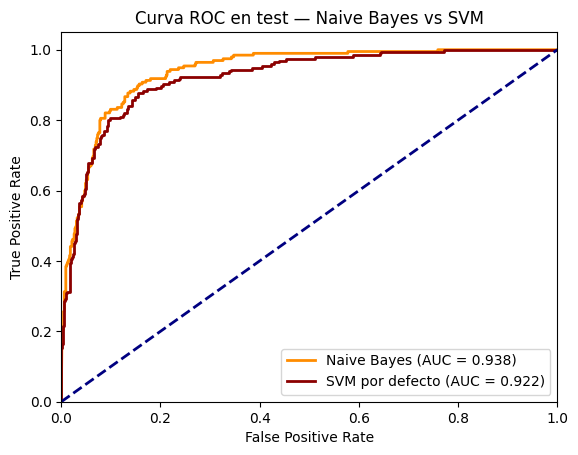

In [13]:
# CURVAS ROC COMPARADAS EN TEST: NAIVE BAYES VS SVM
plt.figure()
lw = 2
plt.plot(res_nb['fpr_test'], res_nb['tpr_test'], color="darkorange", lw=lw,
         label="Naive Bayes (AUC = %0.3f)" % res_nb['auc_test'])
plt.plot(res_svm['fpr_test'], res_svm['tpr_test'], color="darkred", lw=lw,
         label="SVM por defecto (AUC = %0.3f)" % res_svm['auc_test'])
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC en test — Naive Bayes vs SVM")
plt.legend(loc="lower right")
plt.show()

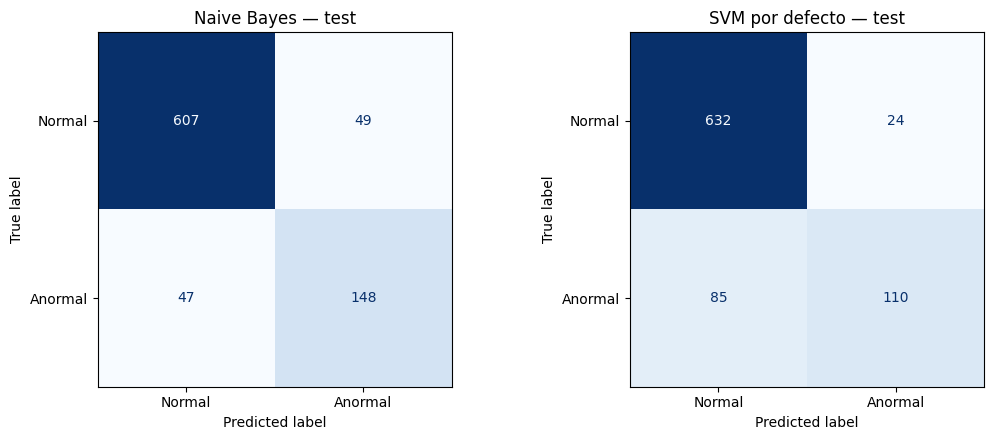

In [14]:
# MATRICES DE CONFUSION (TEST) - NAIVE BAYES VS SVM
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test_nb),
                        display_labels=["Normal", "Anormal"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Naive Bayes — test")
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test_svm),
                        display_labels=["Normal", "Anormal"]).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("SVM por defecto — test")
plt.tight_layout()
plt.show()

**Lo que veo aquí.** Naive Bayes obtiene un AUC de test ligeramente superior al SVM por
defecto y una diferencia pequeña entre AUC de entrenamiento y test en ambos modelos (no hay
sobreajuste relevante en ninguno de los dos). El SVM con valores por defecto comete más falsos
negativos (anormales clasificados como normales), lo que en un contexto clínico es el error más
costoso. Antes de decidir cuál es "el mejor algoritmo posible" pruebo, en la fase adicional, si
ajustar los hiperparámetros del SVM mejora su rendimiento por encima de Naive Bayes.

## Fase adicional — Búsqueda de hiperparámetros para SVM (Grid Search)

Se explora la combinación de kernel/`C`/`gamma` que maximiza el AUC en validación
cruzada (`cv=3`), sobre el conjunto de entrenamiento, igual que en `SVM_Grid_Search.ipynb` del
sprint 6.

In [15]:
# GRID SEARCH SOBRE EL SVM
param_grid = [
    {"kernel": ["rbf"], "gamma": [1e-3, 1e-4], "C": [0.1, 1, 10]},
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
    {"kernel": ["poly"], "C": [0.1, 1, 10], "degree": [2, 3]},
]

grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    scoring="roc_auc",
    n_jobs=-1,
    cv=3,
    verbose=0,
    return_train_score=True,
)
grid.fit(X_train, y_train.values.ravel())

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor AUC medio en validación cruzada: {grid.best_score_:.4f}")

Mejores hiperparámetros: {'C': 1, 'kernel': 'linear'}
Mejor AUC medio en validación cruzada: 0.9610


In [16]:
# MODELO SVM AJUSTADO CON LOS MEJORES HIPERPARAMETROS
modelSVM_tuned = grid.best_estimator_

y_pred_train_svm_t = modelSVM_tuned.predict_proba(X_train)
y_pred_test_svm_t = modelSVM_tuned.predict_proba(X_test)
pred_train_svm_t = modelSVM_tuned.predict(X_train)
pred_test_svm_t = modelSVM_tuned.predict(X_test)

res_svm_t = validar("SVM ajustado (Grid Search)", y_pred_train_svm_t, y_pred_test_svm_t,
                     pred_train_svm_t, pred_test_svm_t)

=== SVM ajustado (Grid Search) ===
AUC   entrenamiento: 0.9710   |   AUC   test: 0.9610
ACC   entrenamiento: 0.9184   |   ACC   test: 0.9048


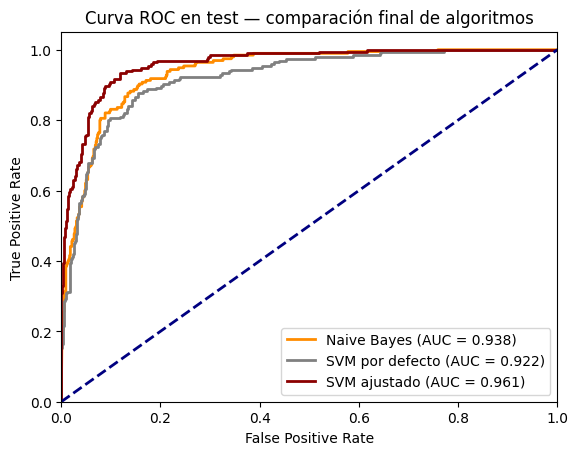

In [17]:
# CURVAS ROC FINALES: NAIVE BAYES VS SVM POR DEFECTO VS SVM AJUSTADO
plt.figure()
lw = 2
plt.plot(res_nb['fpr_test'], res_nb['tpr_test'], color="darkorange", lw=lw,
         label="Naive Bayes (AUC = %0.3f)" % res_nb['auc_test'])
plt.plot(res_svm['fpr_test'], res_svm['tpr_test'], color="gray", lw=lw,
         label="SVM por defecto (AUC = %0.3f)" % res_svm['auc_test'])
plt.plot(res_svm_t['fpr_test'], res_svm_t['tpr_test'], color="darkred", lw=lw,
         label="SVM ajustado (AUC = %0.3f)" % res_svm_t['auc_test'])
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC en test — comparación final de algoritmos")
plt.legend(loc="lower right")
plt.show()

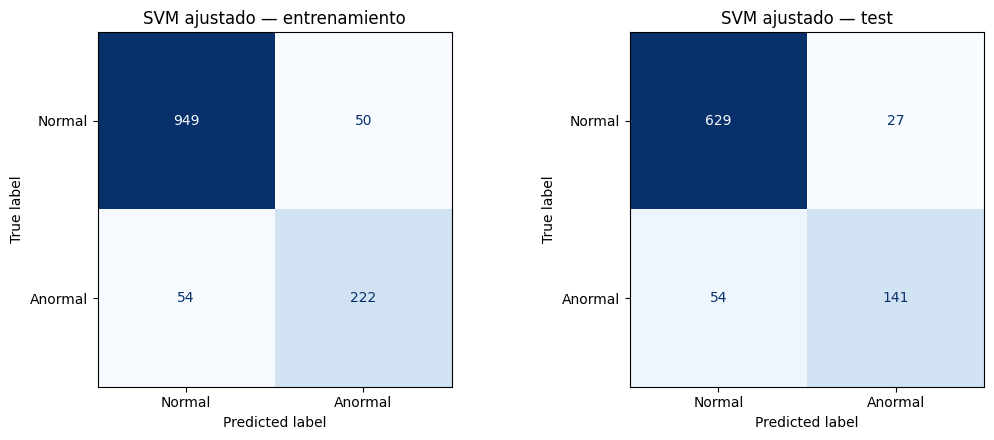

In [18]:
# MATRIZ DE CONFUSION DEL MODELO FINAL (SVM AJUSTADO) - ENTRENAMIENTO Y TEST
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_train, pred_train_svm_t),
                        display_labels=["Normal", "Anormal"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("SVM ajustado — entrenamiento")
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test_svm_t),
                        display_labels=["Normal", "Anormal"]).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("SVM ajustado — test")
plt.tight_layout()
plt.show()

In [19]:
# TABLA RESUMEN DE LOS TRES MODELOS
resumen = pd.DataFrame({
    "Modelo": ["Naive Bayes", "SVM (defecto)", "SVM (Grid Search)"],
    "AUC train": [res_nb['auc_train'], res_svm['auc_train'], res_svm_t['auc_train']],
    "AUC test": [res_nb['auc_test'], res_svm['auc_test'], res_svm_t['auc_test']],
    "ACC train": [res_nb['acc_train'], res_svm['acc_train'], res_svm_t['acc_train']],
    "ACC test": [res_nb['acc_test'], res_svm['acc_test'], res_svm_t['acc_test']],
}).round(4)
resumen

,Modelo,AUC train,AUC test,ACC train,ACC test
0,Naive Bayes,0.9499,0.9381,0.8886,0.8872
1,SVM (defecto),0.9378,0.9217,0.8784,0.8719
2,SVM (Grid Search),0.9710,0.9610,0.9184,0.9048


## Conclusiones finales

- **Algoritmo seleccionado:** SVM con kernel **lineal** y **`C=1`** (resto de hiperparámetros
  por defecto), encontrado mediante `GridSearchCV` optimizando el AUC medio en validación
  cruzada (`cv=3`) sobre las combinaciones de kernel (`rbf`, `linear`, `poly`), `C`
  (0.1, 1, 10), `gamma` (1e-3, 1e-4) y `degree` (2, 3).
- **Rendimiento del modelo final (SVM ajustado):** AUC de test ≈ 0.961 y precisión de test
  ≈ 90.5 %, superando tanto a Naive Bayes (AUC test ≈ 0.938) como al SVM con valores por
  defecto (AUC test ≈ 0.922).
- **Sobreajuste:** la diferencia entre AUC de entrenamiento (≈ 0.971) y de test (≈ 0.961) del
  modelo ajustado es pequeña (~0.01), igual que la diferencia de precisión (≈ 1.4 puntos), lo
  que indica que el modelo generaliza bien y no sobreajusta pese a haber ganado bastante
  complejidad respecto a los valores por defecto.
- **Variable derivada:** combinar `ASTV` y `ALTV` en `Abn_Variability` aportó una variable
  explicativa más informativa que cualquiera de las dos por separado.
- El SVM ajustado en la fase adicional se toma como el algoritmo final entregado para este
  proyecto.